총 11개의 구조에 대해 종합 분석을 시작합니다...
분석 진행 중: structure_000_c1.extxyz (x = 0.00)
분석 진행 중: structure_020_c1.extxyz (x = 0.20)
분석 진행 중: structure_040_c1.extxyz (x = 0.40)
분석 진행 중: structure_060_c1.extxyz (x = 0.60)
분석 진행 중: structure_080_c1.extxyz (x = 0.80)
분석 진행 중: structure_100_c1.extxyz (x = 1.00)
분석 진행 중: structure_120_c1.extxyz (x = 1.20)
분석 진행 중: structure_140_c1.extxyz (x = 1.40)
분석 진행 중: structure_160_c1.extxyz (x = 1.60)
분석 진행 중: structure_180_c1.extxyz (x = 1.80)
분석 진행 중: structure_200_c1.extxyz (x = 2.00)

[완료] 데이터 분석 완료. 시각화 자료를 생성합니다...
모든 작업이 완료되었습니다!
- 조성 데이터: composition_summary.csv / Figure1_Defect_Ratio.png
- MD 다이내믹스 그래프: Figure2_MD_Dynamics_Grid.png
- 최고 품질 VASP 추출 경로: /extracted_ideal_bridges/


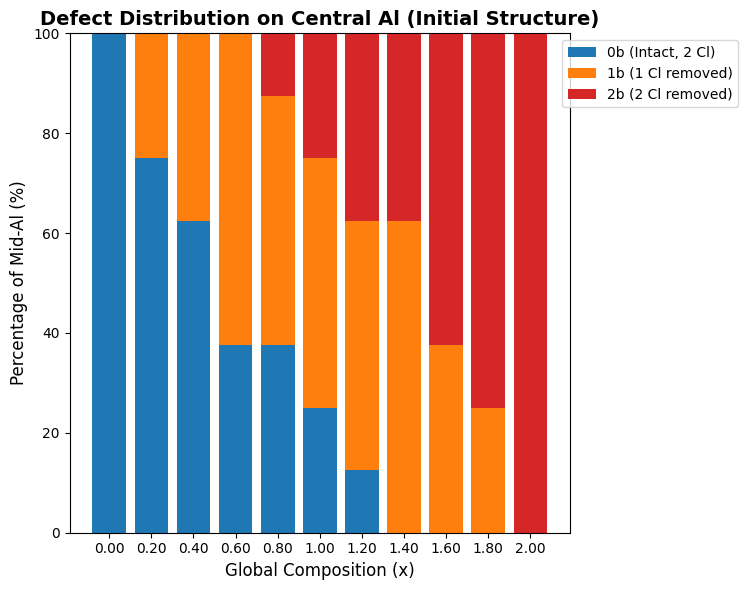

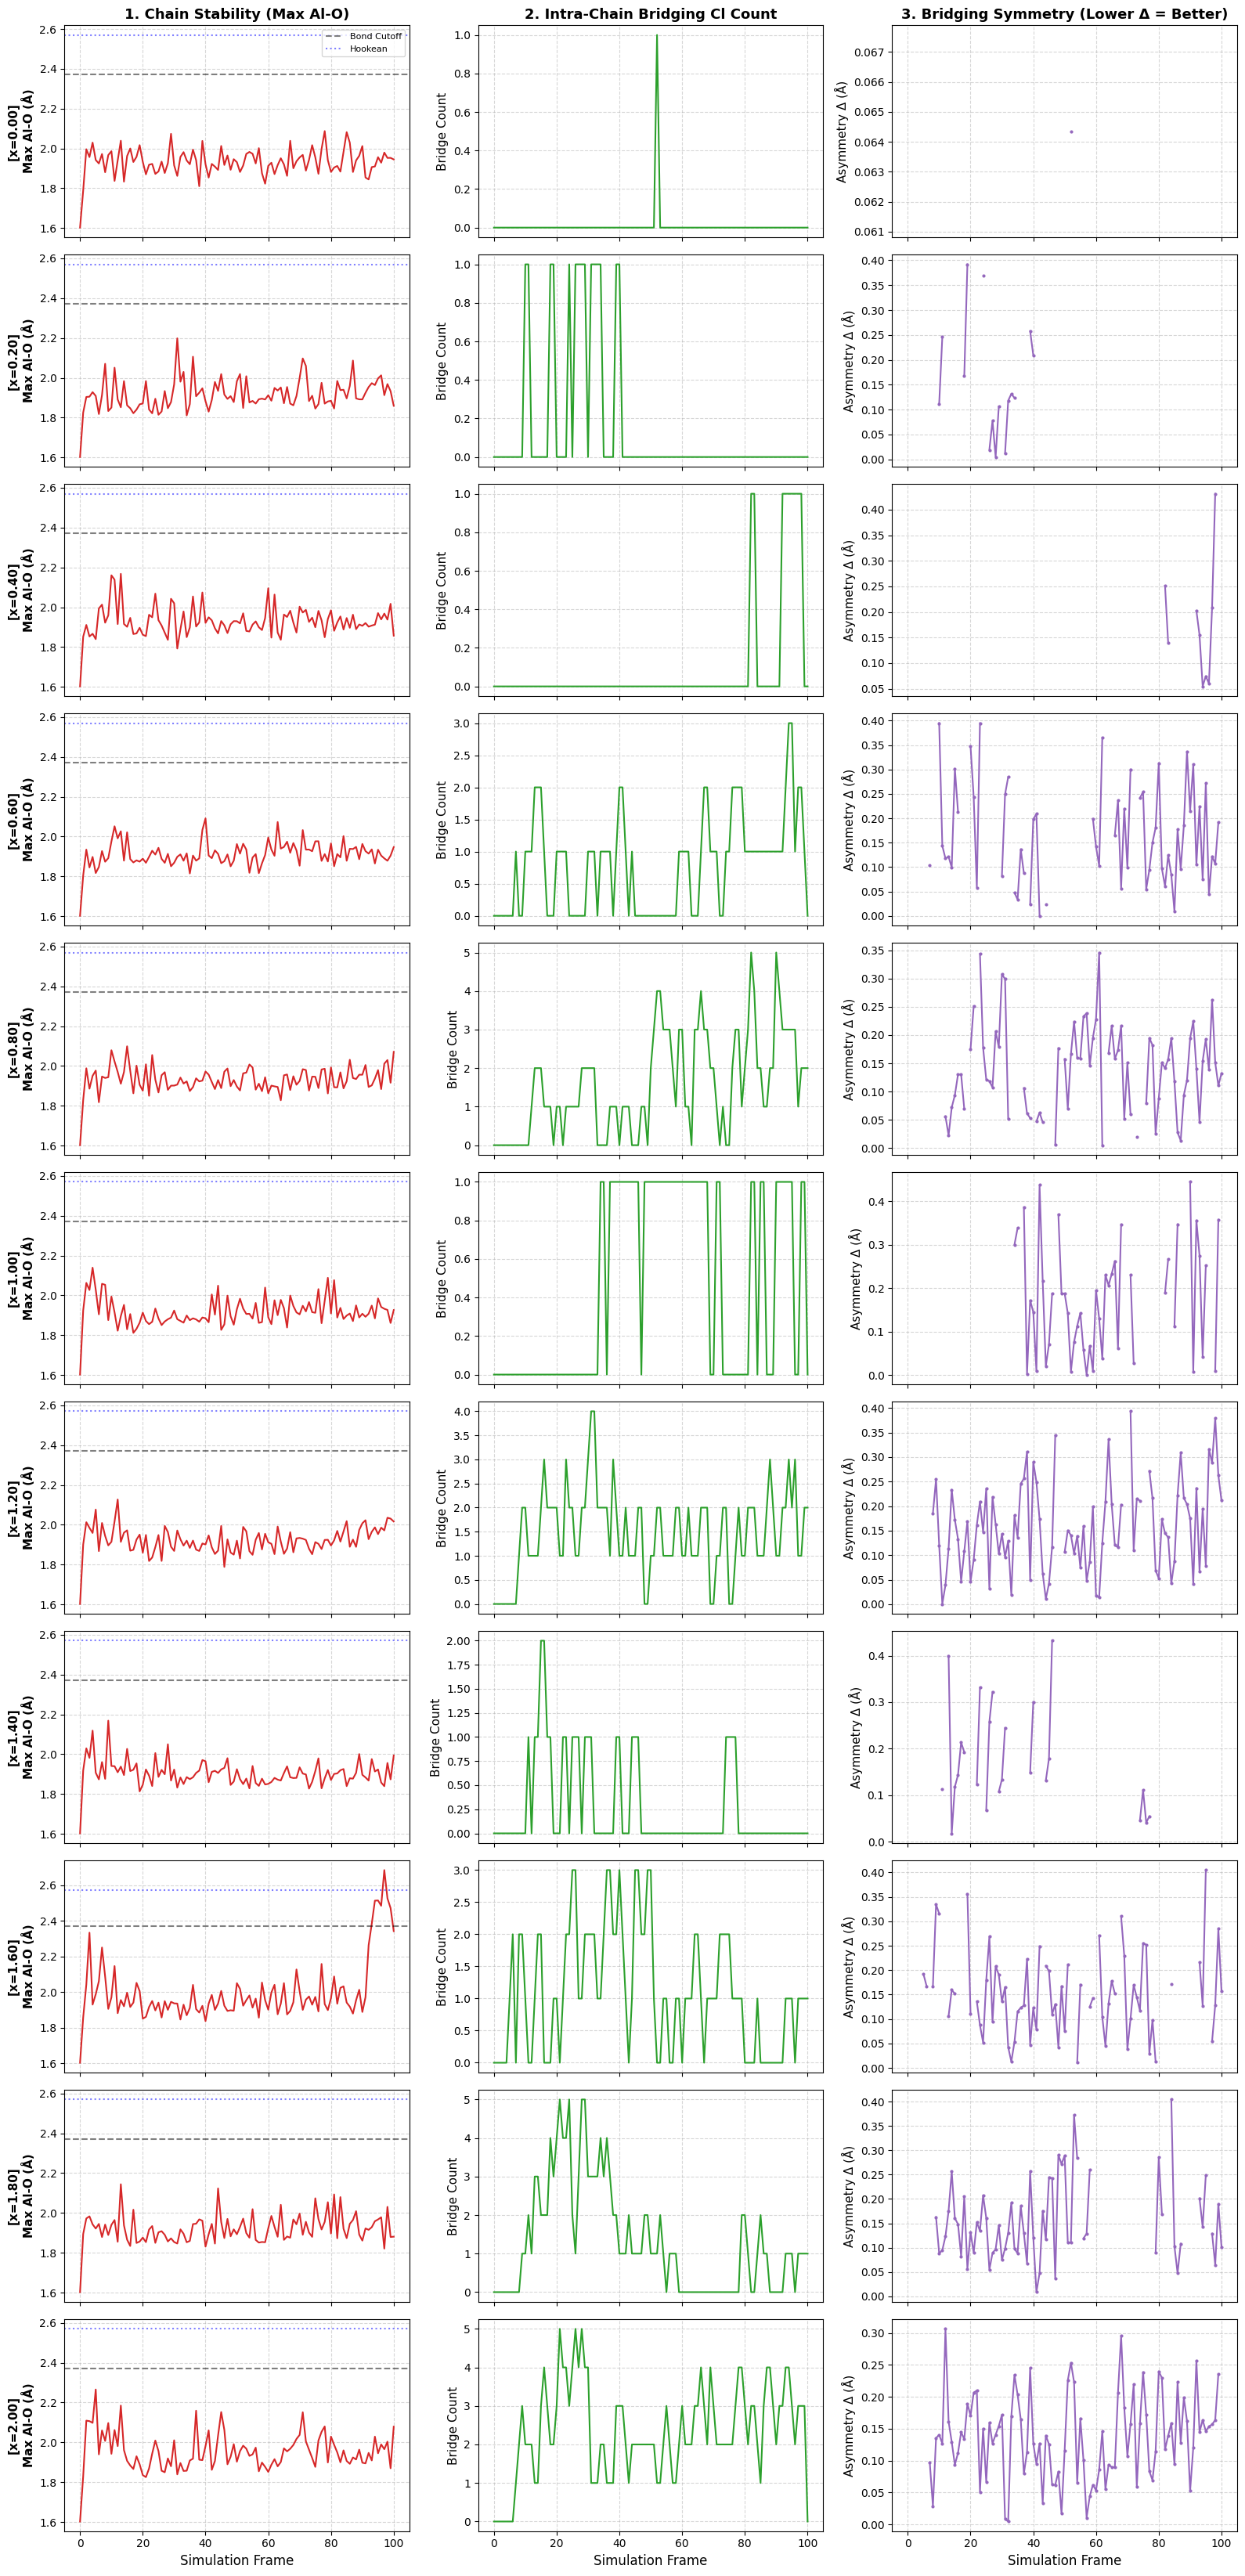

In [4]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ase.io import read, write
from ase.neighborlist import neighbor_list
from ase.data import covalent_radii, atomic_numbers

# ==========================================
# 1. 설정 및 파라미터 
# ==========================================
# MD 계산에서 사용한 반경 및 Cutoff
r_al = covalent_radii[atomic_numbers['Al']]
r_o  = covalent_radii[atomic_numbers['O']]
r_cl = covalent_radii[atomic_numbers['Cl']]

AL_O_BOND_CUTOFF = r_al + r_o + 0.5    # 약 2.42 Å (파괴 기준선)
AL_O_HOOKEAN_RT  = AL_O_BOND_CUTOFF + 0.2  # 약 2.62 Å (복원력 시작선)
AL_CL_CUTOFF     = r_al + r_cl + 0.3   # 약 2.58 Å (Cl 결합 탐색선)

BASE_DIR = "mlmd_extxyz"
VASP_OUT_DIR = "extracted_ideal_bridges"
os.makedirs(VASP_OUT_DIR, exist_ok=True)

# 분석 대상 폴더 탐색
target_folders = sorted([f for f in os.listdir(BASE_DIR) if os.path.isdir(os.path.join(BASE_DIR, f)) and f.startswith("structure_")])

# 데이터 저장을 위한 변수
composition_data = []
md_plot_data = {}

print(f"총 {len(target_folders)}개의 구조에 대해 종합 분석을 시작합니다...\n" + "="*60)

# ==========================================
# 2. 메인 분석 루프
# ==========================================
for folder in target_folders:
    base_name = folder.replace(".extxyz", "")
    traj_file = os.path.join(BASE_DIR, folder, f"{base_name}_nvt.extxyz")
    
    # x 값 추출 (예: structure_030_c1 -> 0.3)
    try:
        x_val = float(base_name.split('_')[1]) / 100.0
    except:
        x_val = 0.0
    
    if not os.path.exists(traj_file):
        continue
        
    print(f"분석 진행 중: {folder} (x = {x_val:.2f})")
    traj = read(traj_file, index=':')
    initial_atoms = traj[0]
    
    chain_ids = initial_atoms.get_array('chain_id')
    al_roles = initial_atoms.get_array('al_role')
    
    # ----------------------------------------------------
    # [목표 1] 초기 구조 결함 분포 (0b, 1b, 2b) 분석
    # ----------------------------------------------------
    cl_i, al_j = neighbor_list('ij', initial_atoms, {('Cl', 'Al'): AL_CL_CUTOFF})
    mid_al_indices = [i for i, role in enumerate(al_roles) if role == 1]
    
    counts = {0: 0, 1: 0, 2: 0} # 2 Cls(0b), 1 Cl(1b), 0 Cl(2b)
    
    for al_idx in mid_al_indices:
        # 이 중앙 Al에 결합된 Cl의 개수 파악
        attached_cls = sum(1 for a in al_j if a == al_idx)
        if attached_cls == 2:
            counts[0] += 1 # 0 broken
        elif attached_cls == 1:
            counts[1] += 1 # 1 broken
        else:
            counts[2] += 1 # 2 broken
            
    total_mid_al = len(mid_al_indices)
    composition_data.append({
        'x_val': x_val,
        'Folder': folder,
        '0b_Count': counts[0],
        '1b_Count': counts[1],
        '2b_Count': counts[2],
        '0b_Ratio(%)': (counts[0]/total_mid_al)*100 if total_mid_al else 0,
        '1b_Ratio(%)': (counts[1]/total_mid_al)*100 if total_mid_al else 0,
        '2b_Ratio(%)': (counts[2]/total_mid_al)*100 if total_mid_al else 0,
    })

    # ----------------------------------------------------
    # [목표 2 & 3] 체인 유지 검증 및 브릿징 품질 분석
    # ----------------------------------------------------
    # 체인 내 초기 Al-O 쌍 식별
    ini_i, ini_j = neighbor_list('ij', initial_atoms, AL_O_BOND_CUTOFF)
    chain_bonds = [(i, j) for i, j in zip(ini_i, ini_j) if i < j and chain_ids[i] == chain_ids[j] and chain_ids[i] > 0 and {initial_atoms[i].symbol, initial_atoms[j].symbol} == {'Al', 'O'}]

    frames, max_dists, bridge_counts, avg_deltas = [], [], [], []
    best_bridge_frames = [] # (품질 점수, 프레임 번호, atoms)

    for f_idx, atoms in enumerate(traj):
        frames.append(f_idx)
        
        # 1. 최대 Al-O 거리 (Hookean)
        max_dist = max([atoms.get_distance(i, j, mic=True) for i, j in chain_bonds]) if chain_bonds else 0
        max_dists.append(max_dist)
        
        # 2. 브릿징 품질 분석
        c_i, a_j = neighbor_list('ij', atoms, {('Cl', 'Al'): AL_CL_CUTOFF})
        cl_to_al = {}
        for c, a in zip(c_i, a_j):
            if atoms[c].symbol == 'Cl':
                cl_to_al.setdefault(c, []).append(a)
                
        frame_bridge_count = 0
        frame_deltas = []
        best_delta_in_frame = float('inf')
        best_mu_in_frame = float('inf')

        for cl_idx, al_indices in cl_to_al.items():
            if len(al_indices) == 2:
                a1, a2 = al_indices
                c1, c2 = chain_ids[a1], chain_ids[a2]
                r1, r2 = al_roles[a1], al_roles[a2]
                
                # 동일 체인 내에서 중앙 Al(1)과 양끝 Al(2)을 잇는 경우
                if c1 == c2 and c1 > 0 and {r1, r2} == {1, 2}:
                    frame_bridge_count += 1
                    d1 = atoms.get_distance(cl_idx, a1, mic=True)
                    d2 = atoms.get_distance(cl_idx, a2, mic=True)
                    
                    delta = abs(d1 - d2)   # 분산 대용 (비대칭도)
                    mu = (d1 + d2) / 2.0   # 평균 결합 길이
                    
                    frame_deltas.append(delta)
                    
                    # 가장 대칭적(delta 낮음)이고 타이트한(mu 낮음) 결합 추적
                    if delta < best_delta_in_frame:
                        best_delta_in_frame = delta
                        best_mu_in_frame = mu
                        
        bridge_counts.append(frame_bridge_count)
        avg_deltas.append(np.mean(frame_deltas) if frame_deltas else np.nan)
        
        if frame_bridge_count > 0:
            # 품질 점수: 비대칭도가 낮을수록(0에 가까울수록), 결합길이가 짧을수록 좋음
            score = best_delta_in_frame + (0.1 * best_mu_in_frame)
            best_bridge_frames.append((score, best_delta_in_frame, best_mu_in_frame, f_idx, atoms))

    md_plot_data[x_val] = {
        'frames': frames, 'max_dists': max_dists, 
        'bridge_counts': bridge_counts, 'avg_deltas': avg_deltas
    }

    # ----------------------------------------------------
    # [목표 4] 최상급 브릿징 구조 VASP 추출 (상위 2개)
    # ----------------------------------------------------
    if best_bridge_frames:
        # 점수가 낮은(우수한) 순으로 정렬
        best_bridge_frames.sort(key=lambda x: x[0])
        top_frames = best_bridge_frames[:2]
        
        out_folder = os.path.join(VASP_OUT_DIR, f"x_{x_val:.2f}")
        os.makedirs(out_folder, exist_ok=True)
        
        for rank, (score, dlt, mu, f_idx, b_atoms) in enumerate(top_frames):
            v_name = f"POSCAR_rank{rank+1}_f{f_idx}_delta{dlt:.3f}.vasp"
            write(os.path.join(out_folder, v_name), b_atoms, format='vasp', sort=True)

# ==========================================
# 3. 데이터 저장 및 시각화 (Figure 1: 결함 비율)
# ==========================================
print("\n[완료] 데이터 분석 완료. 시각화 자료를 생성합니다...")

# # CSV 저장
# df_comp = pd.DataFrame(composition_data).sort_values(by='x_val')
# df_comp.to_csv("composition_summary.csv", index=False)

# CSV 저장
df_comp = pd.DataFrame(composition_data)

# 데이터가 비어있지 않은 경우에만 정렬 실행
if not df_comp.empty:
    df_comp = df_comp.sort_values(by='x_val')

df_comp.to_csv("composition_summary.csv", index=False)


# Figure 1: 누적 막대 그래프
fig1, ax1 = plt.subplots(figsize=(8, 6))
x_labels = [f"{x:.2f}" for x in df_comp['x_val']]
bar_0b = df_comp['0b_Ratio(%)'].values
bar_1b = df_comp['1b_Ratio(%)'].values
bar_2b = df_comp['2b_Ratio(%)'].values

ax1.bar(x_labels, bar_0b, label='0b (Intact, 2 Cl)', color='tab:blue')
ax1.bar(x_labels, bar_1b, bottom=bar_0b, label='1b (1 Cl removed)', color='tab:orange')
ax1.bar(x_labels, bar_2b, bottom=bar_0b + bar_1b, label='2b (2 Cl removed)', color='tab:red')

ax1.set_xlabel("Global Composition (x)", fontsize=12)
ax1.set_ylabel("Percentage of Mid-Al (%)", fontsize=12)
ax1.set_title("Defect Distribution on Central Al (Initial Structure)", fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', bbox_to_anchor=(1.35, 1))
plt.tight_layout()
fig1.savefig("Figure1_Defect_Ratio.png", dpi=300)

# ==========================================
# 4. 데이터 시각화 (Figure 2: MD 궤적 다중 Subplot)
# ==========================================
num_plots = len(md_plot_data)
if num_plots > 0:
    fig2, axs = plt.subplots(num_plots, 3, figsize=(16, 3 * num_plots), sharex=True)
    if num_plots == 1: axs = np.expand_dims(axs, axis=0) # 1행 방어코드

    sorted_x_vals = sorted(md_plot_data.keys())

    for row, x_val in enumerate(sorted_x_vals):
        data = md_plot_data[x_val]
        fr = data['frames']
        
        # Col 0: 체인 유지 및 Hookean
        axs[row, 0].plot(fr, data['max_dists'], color='tab:red')
        axs[row, 0].axhline(y=AL_O_BOND_CUTOFF, color='black', linestyle='--', alpha=0.5, label='Bond Cutoff')
        axs[row, 0].axhline(y=AL_O_HOOKEAN_RT, color='blue', linestyle=':', alpha=0.5, label='Hookean')
        axs[row, 0].set_ylabel(f"[x={x_val:.2f}]\nMax Al-O (Å)", fontsize=11, fontweight='bold')
        axs[row, 0].grid(True, linestyle='--', alpha=0.5)
        
        # Col 1: 브릿징 개수
        axs[row, 1].plot(fr, data['bridge_counts'], color='tab:green')
        axs[row, 1].set_ylabel("Bridge Count", fontsize=11)
        axs[row, 1].grid(True, linestyle='--', alpha=0.5)
        
        # Col 2: 브릿징 대칭성 (Delta)
        # NaN 값은 선을 끊어서 그림 (브릿지가 없는 구간)
        axs[row, 2].plot(fr, data['avg_deltas'], color='tab:purple', marker='o', markersize=2, linestyle='-')
        axs[row, 2].set_ylabel("Asymmetry Δ (Å)", fontsize=11)
        axs[row, 2].grid(True, linestyle='--', alpha=0.5)

    # Title & Legend
    axs[0, 0].set_title("1. Chain Stability (Max Al-O)", fontsize=13, fontweight='bold')
    axs[0, 0].legend(loc='upper right', fontsize=8)
    axs[0, 1].set_title("2. Intra-Chain Bridging Cl Count", fontsize=13, fontweight='bold')
    axs[0, 2].set_title("3. Bridging Symmetry (Lower Δ = Better)", fontsize=13, fontweight='bold')

    for col in range(3):
        axs[-1, col].set_xlabel("Simulation Frame", fontsize=12)

    plt.tight_layout()
    fig2.savefig("Figure2_MD_Dynamics_Grid.png", dpi=300)

print("모든 작업이 완료되었습니다!")
print("- 조성 데이터: composition_summary.csv / Figure1_Defect_Ratio.png")
print("- MD 다이내믹스 그래프: Figure2_MD_Dynamics_Grid.png")
print("- 최고 품질 VASP 추출 경로: /extracted_ideal_bridges/")

In [5]:
# import os
# import glob
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from ase.io import read, write
# from ase.neighborlist import neighbor_list
# from ase.data import covalent_radii, atomic_numbers

# # ==========================================
# # 1. 설정 및 파라미터 
# # ==========================================
# # MD 계산에서 사용한 반경 및 Cutoff
# r_al = covalent_radii[atomic_numbers['Al']]
# r_o  = covalent_radii[atomic_numbers['O']]
# r_cl = covalent_radii[atomic_numbers['Cl']]

# AL_O_BOND_CUTOFF = r_al + r_o + 0.5    # 약 2.42 Å (파괴 기준선)
# AL_O_HOOKEAN_RT  = AL_O_BOND_CUTOFF + 0.2  # 약 2.62 Å (복원력 시작선)
# AL_CL_CUTOFF     = r_al + r_cl + 0.3   # 약 2.58 Å (Cl 결합 탐색선)

# BASE_DIR = "."
# VASP_OUT_DIR = "extracted_ideal_bridges"
# os.makedirs(VASP_OUT_DIR, exist_ok=True)

# # 분석 대상 폴더 탐색
# target_folders = sorted([f for f in os.listdir(BASE_DIR) if os.path.isdir(f) and f.startswith("structure_")])

# # 데이터 저장을 위한 변수
# composition_data = []
# md_plot_data = {}

# print(f"총 {len(target_folders)}개의 구조에 대해 종합 분석을 시작합니다...\n" + "="*60)

# # ==========================================
# # 2. 메인 분석 루프
# # ==========================================
# for folder in target_folders:
#     base_name = folder.replace(".extxyz", "")
#     traj_file = os.path.join(BASE_DIR, folder, f"{base_name}_nvt.extxyz")
    
#     # x 값 추출 (예: structure_030_c1 -> 0.3)
#     try:
#         x_val = float(base_name.split('_')[1]) / 100.0
#     except:
#         x_val = 0.0
    
#     if not os.path.exists(traj_file):
#         continue
        
#     print(f"분석 진행 중: {folder} (x = {x_val:.2f})")
#     traj = read(traj_file, index=':')
#     initial_atoms = traj[0]
    
#     chain_ids = initial_atoms.get_array('chain_id')
#     al_roles = initial_atoms.get_array('al_role')
    
#     # ----------------------------------------------------
#     # [목표 1] 초기 구조 결함 분포 (0b, 1b, 2b) 분석
#     # ----------------------------------------------------
#     cl_i, al_j = neighbor_list('ij', initial_atoms, {('Cl', 'Al'): AL_CL_CUTOFF})
#     mid_al_indices = [i for i, role in enumerate(al_roles) if role == 1]
    
#     counts = {0: 0, 1: 0, 2: 0} # 2 Cls(0b), 1 Cl(1b), 0 Cl(2b)
    
#     for al_idx in mid_al_indices:
#         # 이 중앙 Al에 결합된 Cl의 개수 파악
#         attached_cls = sum(1 for a in al_j if a == al_idx)
#         if attached_cls == 2:
#             counts[0] += 1 # 0 broken
#         elif attached_cls == 1:
#             counts[1] += 1 # 1 broken
#         else:
#             counts[2] += 1 # 2 broken
            
#     total_mid_al = len(mid_al_indices)
#     composition_data.append({
#         'x_val': x_val,
#         'Folder': folder,
#         '0b_Count': counts[0],
#         '1b_Count': counts[1],
#         '2b_Count': counts[2],
#         '0b_Ratio(%)': (counts[0]/total_mid_al)*100 if total_mid_al else 0,
#         '1b_Ratio(%)': (counts[1]/total_mid_al)*100 if total_mid_al else 0,
#         '2b_Ratio(%)': (counts[2]/total_mid_al)*100 if total_mid_al else 0,
#     })

#     # ----------------------------------------------------
#     # [목표 2 & 3] 체인 유지 검증 및 브릿징 품질 분석
#     # ----------------------------------------------------
#     # 체인 내 초기 Al-O 쌍 식별
#     ini_i, ini_j = neighbor_list('ij', initial_atoms, AL_O_BOND_CUTOFF)
#     chain_bonds = [(i, j) for i, j in zip(ini_i, ini_j) if i < j and chain_ids[i] == chain_ids[j] and chain_ids[i] > 0 and {initial_atoms[i].symbol, initial_atoms[j].symbol} == {'Al', 'O'}]

#     frames, max_dists, bridge_counts, avg_deltas = [], [], [], []
#     best_bridge_frames = [] # (품질 점수, 프레임 번호, atoms)

#     for f_idx, atoms in enumerate(traj):
#         frames.append(f_idx)
        
#         # 1. 최대 Al-O 거리 (Hookean)
#         max_dist = max([atoms.get_distance(i, j, mic=True) for i, j in chain_bonds]) if chain_bonds else 0
#         max_dists.append(max_dist)
        
#         # 2. 브릿징 품질 분석
#         c_i, a_j = neighbor_list('ij', atoms, {('Cl', 'Al'): AL_CL_CUTOFF})
#         cl_to_al = {}
#         for c, a in zip(c_i, a_j):
#             if atoms[c].symbol == 'Cl':
#                 cl_to_al.setdefault(c, []).append(a)
                
#         frame_bridge_count = 0
#         frame_deltas = []
#         best_delta_in_frame = float('inf')
#         best_mu_in_frame = float('inf')

#         for cl_idx, al_indices in cl_to_al.items():
#             if len(al_indices) == 2:
#                 a1, a2 = al_indices
#                 c1, c2 = chain_ids[a1], chain_ids[a2]
#                 r1, r2 = al_roles[a1], al_roles[a2]
                
#                 # 동일 체인 내에서 중앙 Al(1)과 양끝 Al(2)을 잇는 경우
#                 if c1 == c2 and c1 > 0 and {r1, r2} == {1, 2}:
#                     frame_bridge_count += 1
#                     d1 = atoms.get_distance(cl_idx, a1, mic=True)
#                     d2 = atoms.get_distance(cl_idx, a2, mic=True)
                    
#                     delta = abs(d1 - d2)   # 분산 대용 (비대칭도)
#                     mu = (d1 + d2) / 2.0   # 평균 결합 길이
                    
#                     frame_deltas.append(delta)
                    
#                     # 가장 대칭적(delta 낮음)이고 타이트한(mu 낮음) 결합 추적
#                     if delta < best_delta_in_frame:
#                         best_delta_in_frame = delta
#                         best_mu_in_frame = mu
                        
#         bridge_counts.append(frame_bridge_count)
#         avg_deltas.append(np.mean(frame_deltas) if frame_deltas else np.nan)
        
#         if frame_bridge_count > 0:
#             # 품질 점수: 비대칭도가 낮을수록(0에 가까울수록), 결합길이가 짧을수록 좋음
#             score = best_delta_in_frame + (0.1 * best_mu_in_frame)
#             best_bridge_frames.append((score, best_delta_in_frame, best_mu_in_frame, f_idx, atoms))

#     md_plot_data[x_val] = {
#         'frames': frames, 'max_dists': max_dists, 
#         'bridge_counts': bridge_counts, 'avg_deltas': avg_deltas
#     }

#     # ----------------------------------------------------
#     # [목표 4] 최상급 브릿징 구조 VASP 추출 (상위 2개)
#     # ----------------------------------------------------
#     if best_bridge_frames:
#         # 점수가 낮은(우수한) 순으로 정렬
#         best_bridge_frames.sort(key=lambda x: x[0])
#         top_frames = best_bridge_frames[:2]
        
#         out_folder = os.path.join(VASP_OUT_DIR, f"x_{x_val:.2f}")
#         os.makedirs(out_folder, exist_ok=True)
        
#         for rank, (score, dlt, mu, f_idx, b_atoms) in enumerate(top_frames):
#             v_name = f"POSCAR_rank{rank+1}_f{f_idx}_delta{dlt:.3f}.vasp"
#             write(os.path.join(out_folder, v_name), b_atoms, format='vasp', sort=True)

# # ==========================================
# # 3. 데이터 저장 및 시각화 (Figure 1: 결함 비율)
# # ==========================================
# print("\n[완료] 데이터 분석 완료. 시각화 자료를 생성합니다...")

# # # CSV 저장
# # df_comp = pd.DataFrame(composition_data).sort_values(by='x_val')
# # df_comp.to_csv("composition_summary.csv", index=False)

# # CSV 저장
# df_comp = pd.DataFrame(composition_data)

# # 데이터가 비어있지 않은 경우에만 정렬 실행
# if not df_comp.empty:
#     df_comp = df_comp.sort_values(by='x_val')

# df_comp.to_csv("composition_summary.csv", index=False)


# # Figure 1: 누적 막대 그래프
# fig1, ax1 = plt.subplots(figsize=(8, 6))
# x_labels = [f"{x:.2f}" for x in df_comp['x_val']]
# bar_0b = df_comp['0b_Ratio(%)'].values
# bar_1b = df_comp['1b_Ratio(%)'].values
# bar_2b = df_comp['2b_Ratio(%)'].values

# ax1.bar(x_labels, bar_0b, label='0b (Intact, 2 Cl)', color='tab:blue')
# ax1.bar(x_labels, bar_1b, bottom=bar_0b, label='1b (1 Cl removed)', color='tab:orange')
# ax1.bar(x_labels, bar_2b, bottom=bar_0b + bar_1b, label='2b (2 Cl removed)', color='tab:red')

# ax1.set_xlabel("Global Composition (x)", fontsize=12)
# ax1.set_ylabel("Percentage of Mid-Al (%)", fontsize=12)
# ax1.set_title("Defect Distribution on Central Al (Initial Structure)", fontsize=14, fontweight='bold')
# ax1.legend(loc='upper right', bbox_to_anchor=(1.35, 1))
# plt.tight_layout()
# fig1.savefig("Figure1_Defect_Ratio.png", dpi=300)

# # ==========================================
# # 4. 데이터 시각화 (Figure 2: MD 궤적 다중 Subplot)
# # ==========================================
# num_plots = len(md_plot_data)
# if num_plots > 0:
#     fig2, axs = plt.subplots(num_plots, 3, figsize=(16, 3 * num_plots), sharex=True)
#     if num_plots == 1: axs = np.expand_dims(axs, axis=0) # 1행 방어코드

#     sorted_x_vals = sorted(md_plot_data.keys())

#     for row, x_val in enumerate(sorted_x_vals):
#         data = md_plot_data[x_val]
#         fr = data['frames']
        
#         # Col 0: 체인 유지 및 Hookean
#         axs[row, 0].plot(fr, data['max_dists'], color='tab:red')
#         axs[row, 0].axhline(y=AL_O_BOND_CUTOFF, color='black', linestyle='--', alpha=0.5, label='Bond Cutoff')
#         axs[row, 0].axhline(y=AL_O_HOOKEAN_RT, color='blue', linestyle=':', alpha=0.5, label='Hookean')
#         axs[row, 0].set_ylabel(f"[x={x_val:.2f}]\nMax Al-O (Å)", fontsize=11, fontweight='bold')
#         axs[row, 0].grid(True, linestyle='--', alpha=0.5)
        
#         # Col 1: 브릿징 개수
#         axs[row, 1].plot(fr, data['bridge_counts'], color='tab:green')
#         axs[row, 1].set_ylabel("Bridge Count", fontsize=11)
#         axs[row, 1].grid(True, linestyle='--', alpha=0.5)
        
#         # Col 2: 브릿징 대칭성 (Delta)
#         # NaN 값은 선을 끊어서 그림 (브릿지가 없는 구간)
#         axs[row, 2].plot(fr, data['avg_deltas'], color='tab:purple', marker='o', markersize=2, linestyle='-')
#         axs[row, 2].set_ylabel("Asymmetry Δ (Å)", fontsize=11)
#         axs[row, 2].grid(True, linestyle='--', alpha=0.5)

#     # Title & Legend
#     axs[0, 0].set_title("1. Chain Stability (Max Al-O)", fontsize=13, fontweight='bold')
#     axs[0, 0].legend(loc='upper right', fontsize=8)
#     axs[0, 1].set_title("2. Intra-Chain Bridging Cl Count", fontsize=13, fontweight='bold')
#     axs[0, 2].set_title("3. Bridging Symmetry (Lower Δ = Better)", fontsize=13, fontweight='bold')

#     for col in range(3):
#         axs[-1, col].set_xlabel("Simulation Frame", fontsize=12)

#     plt.tight_layout()
#     fig2.savefig("Figure2_MD_Dynamics_Grid.png", dpi=300)

# print("모든 작업이 완료되었습니다!")
# print("- 조성 데이터: composition_summary.csv / Figure1_Defect_Ratio.png")
# print("- MD 다이내믹스 그래프: Figure2_MD_Dynamics_Grid.png")
# print("- 최고 품질 VASP 추출 경로: /extracted_ideal_bridges/")

In [ ]:
# import os
# import numpy as np
# from ase.io import read, write
# from ase.neighborlist import neighbor_list

# # 결과를 저장할 최상위 디렉토리 생성
# OUT_DIR_30 = "extracted_30_structures"
# os.makedirs(OUT_DIR_30, exist_ok=True)

# print("총 30개의 VASP 이미지 추출 작업을 시작합니다...")
# print("-" * 60)

# for folder in target_folders:
#     base_name = folder.replace(".extxyz", "") # 이전 버그 수정 반영
#     traj_file = os.path.join(BASE_DIR, folder, f"{base_name}_nvt.extxyz")
    
#     if not os.path.exists(traj_file):
#         continue
        
#     print(f"[{base_name}] 분석 및 추출 진행 중...")
#     traj = read(traj_file, index=':')
#     initial_atoms = traj[0]
    
#     # 초기 속성 배열 로드
#     chain_ids = initial_atoms.get_array('chain_id')
#     al_roles = initial_atoms.get_array('al_role')
    
#     energies = []
#     bridge_frames_info = [] # (score, f_idx)
    
#     for f_idx, atoms in enumerate(traj):
#         # 1. 에너지 로드 (안전하게 get_potential_energy() 혹은 info 에서 가져옴)
#         try:
#             epot = atoms.get_potential_energy()
#         except Exception:
#             epot = atoms.info.get('energy', 0.0)
#         energies.append(epot)
        
#         # 2. 브릿징 품질 평가 로직
#         c_i, a_j = neighbor_list('ij', atoms, {('Cl', 'Al'): AL_CL_CUTOFF})
#         cl_to_al = {}
#         for c, a in zip(c_i, a_j):
#             if atoms[c].symbol == 'Cl':
#                 cl_to_al.setdefault(c, []).append(a)
                
#         best_delta_in_frame = float('inf')
#         best_mu_in_frame = float('inf')
#         has_bridge = False
        
#         for cl_idx, al_indices in cl_to_al.items():
#             if len(al_indices) == 2:
#                 a1, a2 = al_indices
#                 c1, c2 = chain_ids[a1], chain_ids[a2]
#                 r1, r2 = al_roles[a1], al_roles[a2]
                
#                 if c1 == c2 and c1 > 0 and {r1, r2} == {1, 2}:
#                     has_bridge = True
#                     d1 = atoms.get_distance(cl_idx, a1, mic=True)
#                     d2 = atoms.get_distance(cl_idx, a2, mic=True)
#                     delta = abs(d1 - d2)
#                     mu = (d1 + d2) / 2.0
#                     if delta < best_delta_in_frame:
#                         best_delta_in_frame = delta
#                         best_mu_in_frame = mu
                        
#         if has_bridge:
#             score = best_delta_in_frame + (0.1 * best_mu_in_frame)
#             bridge_frames_info.append((score, f_idx))
            
#     energies = np.array(energies)
#     all_indices = np.arange(len(traj))
#     selected_indices = set()
#     final_selections = [] # (category, rank, f_idx)
    
#     # ============================================================
#     # [조건 1] Bridging 우수 구조 최대 10개
#     # ============================================================
#     bridge_frames_info.sort(key=lambda x: x[0]) # 비대칭도가 낮을수록(우수할수록) 앞에 배치
#     target1_idx = []
#     for score, f_idx in bridge_frames_info:
#         if f_idx not in selected_indices:
#             target1_idx.append(f_idx)
#             selected_indices.add(f_idx)
#         if len(target1_idx) == 10:
#             break
            
#     for rank, f_idx in enumerate(target1_idx):
#         final_selections.append(("1_Bridging", rank + 1, f_idx))
        
#     # ============================================================
#     # [조건 2] Local Minima + Low Energy 10개
#     # ============================================================
#     local_minima = []
#     # Local minima 탐색 (양옆의 프레임보다 에너지가 낮은 지점)
#     for i in range(1, len(energies) - 1):
#         if energies[i] < energies[i-1] and energies[i] < energies[i+1]:
#             local_minima.append(i)
            
#     # 아직 선택 안 된 minima 중 에너지 오름차순(가장 낮은 것 우선)
#     available_minima = [i for i in local_minima if i not in selected_indices]
#     available_minima.sort(key=lambda i: energies[i])
    
#     target2_idx = available_minima[:10]
#     for idx in target2_idx:
#         selected_indices.add(idx)
        
#     # 만약 minima 구조 중 10개를 채우지 못했다면 남은 프레임 중 에너지가 가장 낮은 녀석으로 채움
#     if len(target2_idx) < 10:
#         shortfall = 10 - len(target2_idx)
#         remaining_indices = [i for i in all_indices if i not in selected_indices]
#         remaining_indices.sort(key=lambda i: energies[i]) # 낮은 에너지 순
        
#         fill_idx = remaining_indices[:shortfall]
#         target2_idx.extend(fill_idx)
#         for idx in fill_idx:
#             selected_indices.add(idx)
            
#     for rank, f_idx in enumerate(target2_idx):
#         final_selections.append(("2_LocalMinLowEnergy", rank + 1, f_idx))
        
#     # ============================================================
#     # [조건 3] 나머지 구조 중 에너지가 가장 높은 10개
#     # ============================================================
#     remaining_indices = [i for i in all_indices if i not in selected_indices]
#     remaining_indices.sort(key=lambda i: energies[i], reverse=True) # 높은 에너지 순
#     target3_idx = remaining_indices[:10]
    
#     for rank, f_idx in enumerate(target3_idx):
#         selected_indices.add(f_idx)
#         final_selections.append(("3_HighEnergy", rank + 1, f_idx))
        
#     # ============================================================
#     # 결과 VASP 저장
#     # ============================================================
#     target_out_dir = os.path.join(OUT_DIR_30, base_name)
#     os.makedirs(target_out_dir, exist_ok=True)
    
#     for cat, rank, f_idx in final_selections:
#         atoms_to_save = traj[f_idx]
        
#         # 폴더 및 파일명 양식: 카테고리_랭크_프레임
#         struct_name = f"{cat}_rank{rank}_f{f_idx}"
        
#         # 개별 구조의 이름으로된 전용 하위 디렉토리 생성
#         # 예시: extracted_30_structures/structure_020_c1/1_Bridging_rank1_f10/
#         image_dir_path = os.path.join(target_out_dir, struct_name)
#         os.makedirs(image_dir_path, exist_ok=True)
        
#         # 생성된 전용 파일 폴더 내부에 원래 구조 이름의 .vasp 파일 저장
#         save_path = os.path.join(image_dir_path, f"{struct_name}.vasp")
#         # 만약 곧바로 VASP를 돌리셔야 해서 파일명이 무조건 POSCAR 이어야 한다면 
#         # save_path = os.path.join(image_dir_path, "POSCAR") 처럼 수정하셔도 좋습니다.
        
#         write(save_path, atoms_to_save, format='vasp', sort=True)
        
#     print(f"  -> {len(final_selections)}개 구조를 각각 개별 폴더에 저장 완료 ({target_out_dir}/)")


# print("-" * 60)
# print(f"[완료] 모든 구조에 대한 30개 이미지 추출 및 저장이 '{OUT_DIR_30}' 경로에 완료되었습니다!")


총 30개의 VASP 이미지 추출 작업을 시작합니다...
------------------------------------------------------------
[structure_000_c1] 분석 및 추출 진행 중...
  -> 21개 구조를 각각 개별 폴더에 저장 완료 (extracted_30_structures/structure_000_c1/)
[structure_020_c1] 분석 및 추출 진행 중...
  -> 30개 구조를 각각 개별 폴더에 저장 완료 (extracted_30_structures/structure_020_c1/)
[structure_040_c1] 분석 및 추출 진행 중...
  -> 29개 구조를 각각 개별 폴더에 저장 완료 (extracted_30_structures/structure_040_c1/)
[structure_060_c1] 분석 및 추출 진행 중...
  -> 30개 구조를 각각 개별 폴더에 저장 완료 (extracted_30_structures/structure_060_c1/)
[structure_080_c1] 분석 및 추출 진행 중...
  -> 30개 구조를 각각 개별 폴더에 저장 완료 (extracted_30_structures/structure_080_c1/)
[structure_100_c1] 분석 및 추출 진행 중...
  -> 30개 구조를 각각 개별 폴더에 저장 완료 (extracted_30_structures/structure_100_c1/)
[structure_120_c1] 분석 및 추출 진행 중...
  -> 30개 구조를 각각 개별 폴더에 저장 완료 (extracted_30_structures/structure_120_c1/)
[structure_140_c1] 분석 및 추출 진행 중...
  -> 30개 구조를 각각 개별 폴더에 저장 완료 (extracted_30_structures/structure_140_c1/)
[structure_160_c1] 분석 및 추출 진행 중...
  -> 30개

In [4]:
# import os
# import numpy as np
# from ase.io import read, write
# from ase.neighborlist import neighbor_list
# from ase.data import covalent_radii, atomic_numbers

# # ==========================================
# # 1. 설정 및 파라미터
# # ==========================================
# # Al-Cl 결합 판단 기준 (MD 코드와 동일하게 설정)
# r_al = covalent_radii[atomic_numbers['Al']]
# r_cl = covalent_radii[atomic_numbers['Cl']]
# AL_CL_CUTOFF = r_al + r_cl + 0.3 

# BASE_DIR = "."
# MAIN_OUTPUT_DIR = "finetuning_dataset" # 병합된 최상위 저장 폴더

# # 추출할 구조 개수 설정
# MAX_BRIDGE_SAMPLES = 10
# MAX_LOW_ENERGY_SAMPLES = 10
# MAX_HIGH_ENERGY_SAMPLES = 10

# # 분석할 폴더 탐색
# target_folders = sorted([
#     f for f in os.listdir(BASE_DIR) 
#     if os.path.isdir(os.path.join(BASE_DIR, f)) and f.startswith("structure_")
# ])

# def get_bridging_cl_count(atoms):
#     """현재 프레임에서 Intra-chain Bridging Cl의 개수를 반환"""
#     # 체인 정보가 없는 경우를 대비한 예외 처리
#     if 'chain_id' not in atoms.arrays:
#         return 0
        
#     chain_ids = atoms.get_array('chain_id')
#     cl_i, al_j = neighbor_list('ij', atoms, {('Cl', 'Al'): AL_CL_CUTOFF})
    
#     cl_to_al = {}
#     for c, a in zip(cl_i, al_j):
#         if atoms[c].symbol == 'Cl':
#             if c not in cl_to_al: cl_to_al[c] = []
#             cl_to_al[c].append(a)
    
#     count = 0
#     for cl_idx, al_indices in cl_to_al.items():
#         if len(al_indices) == 2:
#             c1, c2 = chain_ids[al_indices[0]], chain_ids[al_indices[1]]
#             if c1 == c2 and c1 > 0:
#                 count += 1
#     return count

# def get_energy(atoms):
#     """프레임의 에너지를 반환 (extxyz info field에서 추출)"""
#     try:
#         return atoms.get_potential_energy()
#     except:
#         return atoms.info.get('energy', 0.0)

# # ==========================================
# # 2. 메인 분석 및 추출 루프
# # ==========================================
# print(f"데이터 추출 시작 (대상 폴더: {len(target_folders)}개)\n")

# for folder in target_folders:
#     base_name = folder.replace(".extxyz", "")
#     traj_file = os.path.join(BASE_DIR, folder, f"{base_name}_nvt.extxyz")
    
#     if not os.path.exists(traj_file):
#         continue

#     print(f"분석 중: {folder} ...")
#     try:
#         traj = read(traj_file, index=':')
#     except Exception as e:
#         print(f"  -> 파일 읽기 실패: {e}")
#         continue
    
#     frame_data = []
#     for idx, atoms in enumerate(traj):
#         b_count = get_bridging_cl_count(atoms)
#         energy = get_energy(atoms)
#         frame_data.append({
#             'index': idx,
#             'bridge_count': b_count,
#             'energy': energy,
#             'atoms': atoms
#         })

#     # --- 선별 전략 1: Bridging Cl이 많은 순서 (상위 5개) ---
#     bridge_candidates = [f for f in frame_data if f['bridge_count'] > 0]
#     bridge_candidates.sort(key=lambda x: x['bridge_count'], reverse=True)
#     selected_bridge = bridge_candidates[:MAX_BRIDGE_SAMPLES]

#     # --- 선별 전략 2: 에너지가 낮은 순서 (상위 5개) ---
#     energy_sorted = sorted(frame_data, key=lambda x: x['energy'])
#     selected_low_energy = energy_sorted[:MAX_LOW_ENERGY_SAMPLES]

#     # --- 선별 전략 3: 에너지가 높은 순서 (상위 5개) ---
#     selected_high_energy = energy_sorted[-MAX_HIGH_ENERGY_SAMPLES:]
#     selected_high_energy.reverse() # 가장 높은 에너지가 먼저 오도록 정렬

#     # --- 파일 저장 루프 ---
#     to_save = [
#         (selected_bridge, "bridge"),
#         (selected_low_energy, "low_energy"),
#         (selected_high_energy, "high_energy")
#     ]

#     for dataset, feature_name in to_save:
#         for item in dataset:
#             f_idx = item['index']
            
#             # 특징 이름 생성 및 폴더명/파일명 지정
#             if feature_name == "bridge":
#                 val = item['bridge_count']
#                 feature_tag = f"f{f_idx}_bridge{int(val)}"
#             elif feature_name == "low_energy":
#                 val = item['energy']
#                 feature_tag = f"f{f_idx}_lowEnergy_{val:.2f}"
#             elif feature_name == "high_energy":
#                 val = item['energy']
#                 feature_tag = f"f{f_idx}_highEnergy_{val:.2f}"

#             # 최종 경로 설정: finetuning_dataset/structure_030_c1/f120_bridge3/f120_bridge3.vasp
#             save_path = os.path.join(MAIN_OUTPUT_DIR, base_name, feature_tag)
#             if not os.path.exists(save_path):
#                 os.makedirs(save_path)
            
#             file_name = f"{feature_tag}.vasp"
#             write(os.path.join(save_path, file_name), item['atoms'], format='vasp', vasp5=True, sort=True)

#     print(f"  -> 추출 완료: Bridging({len(selected_bridge)}), 저에너지({len(selected_low_energy)}), 고에너지({len(selected_high_energy)})")

# print(f"\n모든 작업이 완료되었습니다. 결과 폴더: {MAIN_OUTPUT_DIR}")